![banner](../../../docs/figs/brand_identity/banner.png)

# Week 9: Next-Token Probabilities and Hallucination

## Lesson overview

Explore which next tokens a model gives higher probabilities after a particular context. Compare clear, open-ended, and fictional-fact prompts. The input is a prompt; the outputs are candidate-token probabilities and generated text.

**By the end, you can:** read a candidate-probability plot; compare how context changes the candidates; and explain why a low or flat distribution alone cannot prove that a model will invent facts.

**Before you begin:** The first run downloads a model from Hugging Face and needs an internet connection and access. The DeepSeek comparison also needs API credentials. The model may use substantial memory.

## Part 1 — Next-token probabilities

The comparison is between candidate next tokens given the current context. A probability plot shows only one-step predictions from this model and tokenizer.

# Week 9: Understanding LLM Hallucination Through Next-Token Prediction

**Goal**: Understand why Large Language Models (LLMs) hallucinate by exploring the fundamental mechanism of next-token prediction.

---

## Part 1 — Concept: What Is Next-Token Prediction?

Follow the example one piece at a time. Each generated piece changes the context and therefore the next candidates.

### A context changes the next-token distribution

The bars here are a concept sketch, not measured model output. The cells below calculate results for the selected model.

In [1]:
# Setup: Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers import GPT2Tokenizer, GPT2Model, GPT2LMHeadModel
import warnings
warnings.filterwarnings('ignore')

# Import from our toolkit
from ccai9012.llm_utils import initialize_llm, ask_llm
from ccai9012.sd_utils import get_hf_api_key

In [2]:
hf_token = get_hf_api_key()

model_name = "EleutherAI/gpt-neo-1.3B"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=hf_token)
model = AutoModelForCausalLM.from_pretrained(model_name, use_auth_token=hf_token)

print(f"Loaded {model_name} successfully!")

Enter your HUGGINGFACE_API_KEY:  ········


Loaded EleutherAI/gpt-neo-1.3B successfully!


In [3]:
def get_next_token_probabilities(prompt, tokenizer, model, top_k=10):
    """
    Get the top-k most probable next tokens and their probabilities.
    
    Args:
        prompt (str): Input text
        tokenizer: Hugging Face tokenizer
        model: Hugging Face language model
        top_k (int): Number of top tokens to return
    
    Returns:
        tuple: (tokens, probabilities)
    """
    # Tokenize input
    input_ids = tokenizer.encode(prompt, return_tensors="pt")
    
    # Get model output (logits)
    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits
    
    # Get logits for the last token (next token prediction)
    next_token_logits = logits[0, -1, :]
    
    # Convert logits to probabilities using softmax
    probabilities = torch.softmax(next_token_logits, dim=0)
    
    # Get top-k tokens
    top_probs, top_indices = torch.topk(probabilities, top_k)
    
    # Decode tokens
    top_tokens = [tokenizer.decode([idx]) for idx in top_indices]
    
    return top_tokens, top_probs.numpy()

## Part 2 — Example 1: Clear, Unambiguous Prompt

Use a clear prompt to see whether candidates are concentrated. After running the cell, inspect the highest-probability item and compare it with the others.

In [4]:
# Example 1: Clear, unambiguous prompt
# prompt1 = "1 + 1 ="
prompt1 = "Just give me the city name. The capital of France is"

tokens1, probs1 = get_next_token_probabilities(prompt1, tokenizer, model, top_k=10)

print(f"Prompt: '{prompt1}'\n")
print("Top 10 next-token predictions:")
print("-" * 40)
for token, prob in zip(tokens1, probs1):
    print(f"{token:20s} → {prob:.4f} ({prob*100:.2f}%)")

Prompt: 'Just give me the city name. The capital of France is'

Top 10 next-token predictions:
----------------------------------------
 Paris               → 0.4398 (43.98%)
 not                 → 0.0697 (6.97%)
 in                  → 0.0647 (6.47%)
 called              → 0.0331 (3.31%)
 the                 → 0.0317 (3.17%)
 Lyon                → 0.0152 (1.52%)
 a                   → 0.0106 (1.06%)
 B                   → 0.0089 (0.89%)

                    → 0.0082 (0.82%)
 Mont                → 0.0081 (0.81%)


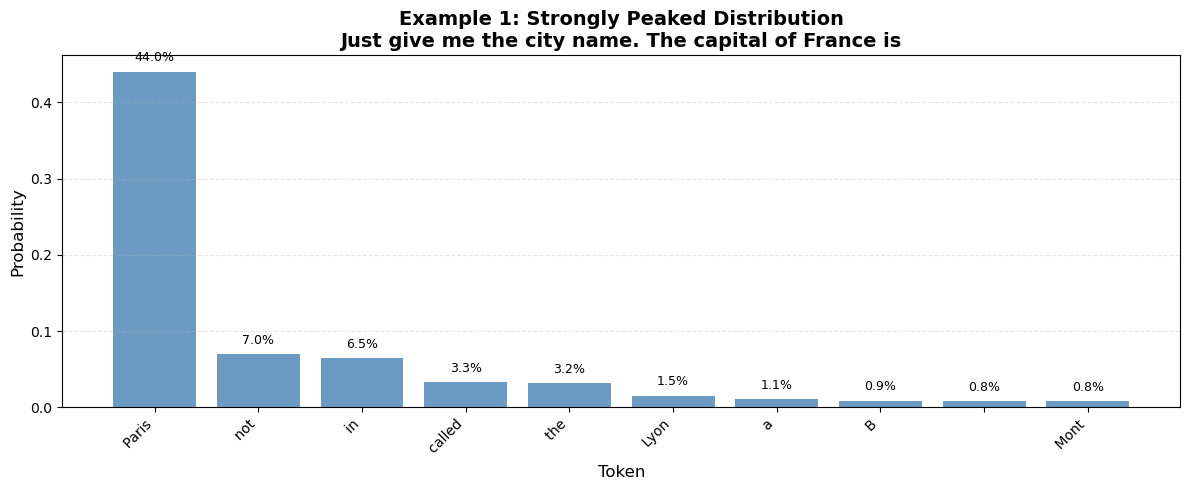


Observation: Notice how ONE token dominates the probability distribution!


In [5]:
# Visualize Example 1
plt.figure(figsize=(12, 5))

plt.bar(range(len(tokens1)), probs1, color='steelblue', alpha=0.8)
plt.xticks(range(len(tokens1)), tokens1, rotation=45, ha='right')
plt.ylabel('Probability', fontsize=12)
plt.xlabel('Token', fontsize=12)
plt.title(f'Example 1: Strongly Peaked Distribution\n{prompt1}', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on bars
for i, (token, prob) in enumerate(zip(tokens1, probs1)):
    plt.text(i, prob + 0.01, f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nObservation: Notice how ONE token dominates the probability distribution!")

## Part 3 — Example 2: Ambiguous Prompt (Multiple High Probabilities)

An open-ended prompt can have several reasonable continuations. The plotted candidates are limited by the tokenizer and are not probabilities of complete answers.

In [6]:
# Example 2: Ambiguous prompt
prompt2 = "The coolest city in China is"

tokens2, probs2 = get_next_token_probabilities(prompt2, tokenizer, model, top_k=10)

print(f"Prompt: '{prompt2}'\n")
print("Top 10 next-token predictions:")
print("-" * 40)
for token, prob in zip(tokens2, probs2):
    print(f"{token:20s} → {prob:.4f} ({prob*100:.2f}%)")

Prompt: 'The coolest city in China is'

Top 10 next-token predictions:
----------------------------------------
 Beijing             → 0.0881 (8.81%)
 also                → 0.0698 (6.98%)
 the                 → 0.0684 (6.84%)
 a                   → 0.0455 (4.55%)
 now                 → 0.0333 (3.33%)
 Shanghai            → 0.0326 (3.26%)
 not                 → 0.0248 (2.48%)
 one                 → 0.0184 (1.84%)
 actually            → 0.0154 (1.54%)
 Nan                 → 0.0139 (1.39%)


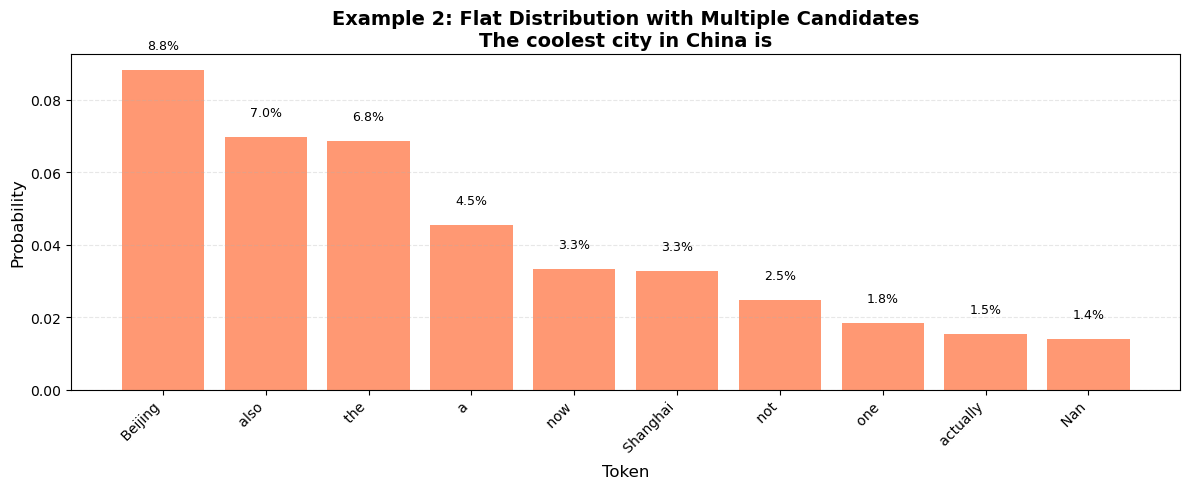


Observation: The distribution is much FLATTER - multiple tokens are plausible!


In [7]:
# Visualize Example 2
plt.figure(figsize=(12, 5))

plt.bar(range(len(tokens2)), probs2, color='coral', alpha=0.8)
plt.xticks(range(len(tokens2)), tokens2, rotation=45, ha='right')
plt.ylabel('Probability', fontsize=12)
plt.xlabel('Token', fontsize=12)
plt.title(f'Example 2: Flat Distribution with Multiple Candidates\n{prompt2}', 
          fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add percentage labels on bars
for i, (token, prob) in enumerate(zip(tokens2, probs2)):
    plt.text(i, prob + 0.005, f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nObservation: The distribution is much FLATTER - multiple tokens are plausible!")

## Part 4 — Side-by-Side Comparison

When comparing the prompts side by side, remember that their different contexts may explain changes in the distribution.

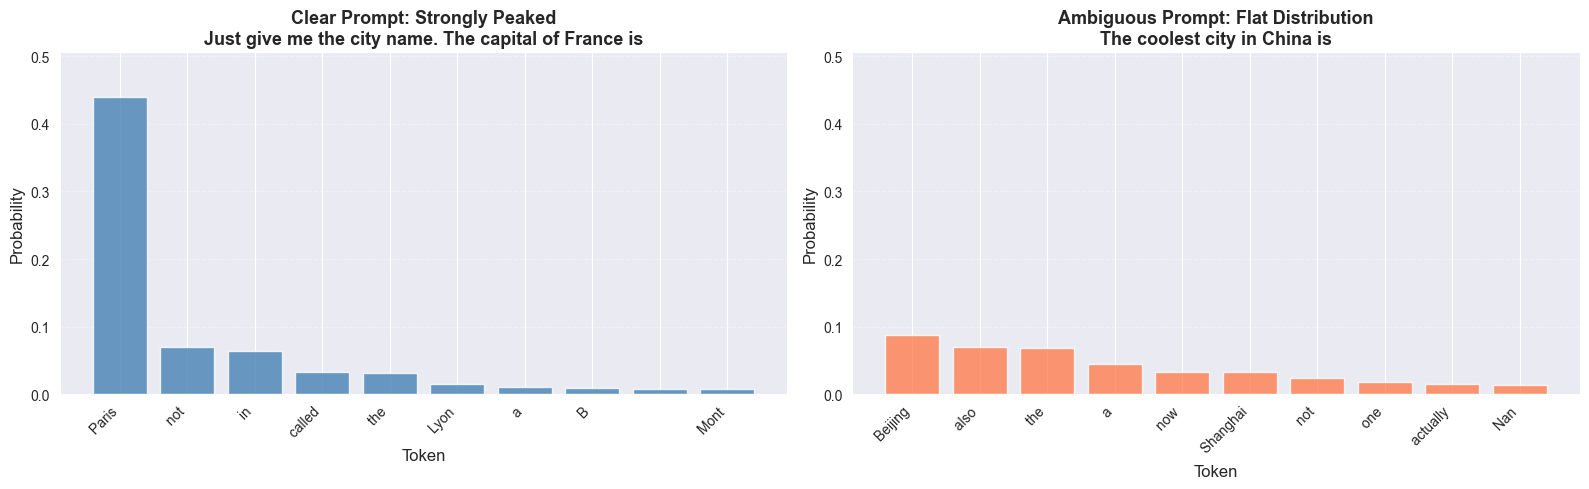


Key Insight:
  • LEFT: High certainty → One dominant answer
  • RIGHT: High uncertainty → Multiple plausible answers


In [10]:
# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Clear prompt
axes[0].bar(range(len(tokens1)), probs1, color='steelblue', alpha=0.8)
axes[0].set_xticks(range(len(tokens1)))
axes[0].set_xticklabels(tokens1, rotation=45, ha='right')
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].set_xlabel('Token', fontsize=12)
axes[0].set_title(f'Clear Prompt: Strongly Peaked\n{prompt1}', 
                   fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim(0, max(max(probs1), max(probs2)) * 1.15)

# Plot 2: Ambiguous prompt
axes[1].bar(range(len(tokens2)), probs2, color='coral', alpha=0.8)
axes[1].set_xticks(range(len(tokens2)))
axes[1].set_xticklabels(tokens2, rotation=45, ha='right')
axes[1].set_ylabel('Probability', fontsize=12)
axes[1].set_xlabel('Token', fontsize=12)
axes[1].set_title(f'Ambiguous Prompt: Flat Distribution\n{prompt2}', 
                   fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].set_ylim(0, max(max(probs1), max(probs2)) * 1.15)

plt.tight_layout()
plt.show()

print("\nKey Insight:")
print("  • LEFT: High certainty → One dominant answer")
print("  • RIGHT: High uncertainty → Multiple plausible answers")

## Part 5 — Hallucination Demonstration

The fictional book example shows how a model continues a prompt; it does not prove that every low-probability output is a hallucination. Check whether the generated claims can be verified.

In [11]:
# Hallucination Example: Non-existent book
prompt_hallucination = "The book 'Blue Dragons of Mars' was written by"

tokens_hall, probs_hall = get_next_token_probabilities(prompt_hallucination, tokenizer, model, top_k=10)

print(f"Prompt: '{prompt_hallucination}'\n")
print("Top 10 next-token predictions:")
print("-" * 40)
for token, prob in zip(tokens_hall, probs_hall):
    print(f"{token:20s} → {prob:.4f} ({prob*100:.2f}%)")

Prompt: 'The book 'Blue Dragons of Mars' was written by'

Top 10 next-token predictions:
----------------------------------------
 the                 → 0.0692 (6.92%)
 a                   → 0.0534 (5.34%)
 Dr                  → 0.0337 (3.37%)
 John                → 0.0201 (2.01%)
 an                  → 0.0196 (1.96%)
 David               → 0.0160 (1.60%)
 Professor           → 0.0155 (1.55%)
 Robert              → 0.0111 (1.11%)
 J                   → 0.0110 (1.10%)
 American            → 0.0104 (1.04%)


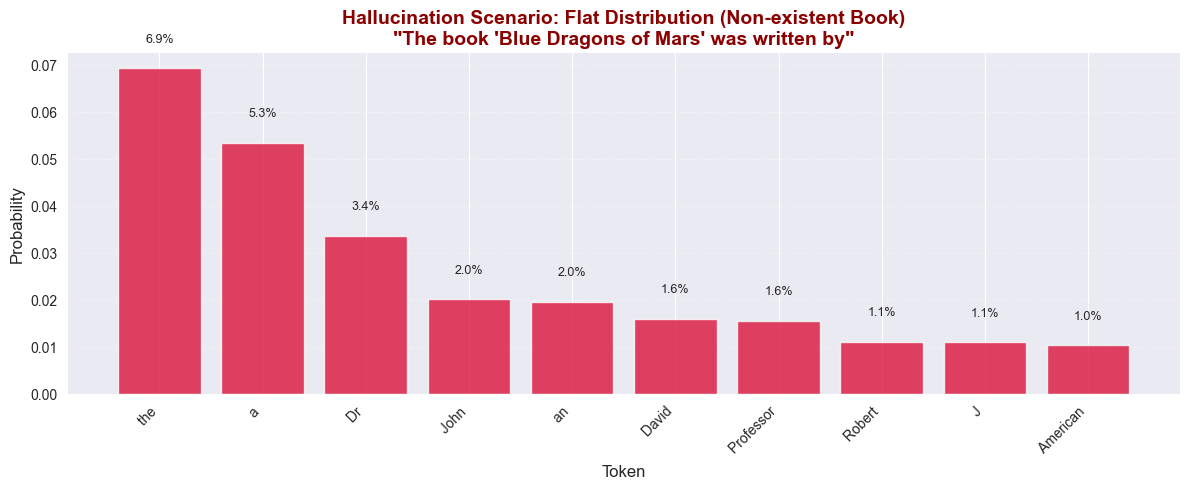

In [12]:
# Visualize hallucination probability distribution
plt.figure(figsize=(12, 5))

plt.bar(range(len(tokens_hall)), probs_hall, color='crimson', alpha=0.8)
plt.xticks(range(len(tokens_hall)), tokens_hall, rotation=45, ha='right')
plt.ylabel('Probability', fontsize=12)
plt.xlabel('Token', fontsize=12)
plt.title('Hallucination Scenario: Flat Distribution (Non-existent Book)\n"The book \'Blue Dragons of Mars\' was written by"', 
          fontsize=14, fontweight='bold', color='darkred')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for i, (token, prob) in enumerate(zip(tokens_hall, probs_hall)):
    plt.text(i, prob + 0.005, f'{prob*100:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
# Generate full answer with the same prompt
from transformers import pipeline
generator = pipeline('text-generation', model=model_name)
generator(prompt_hallucination, do_sample=True, min_length=50)

Device set to use mps:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "The book 'Blue Dragons of Mars' was written by the late Professor Peter David, one of the 'Fathers of Archaeology' for whom Mars never had the right conditions for an inhabited world. The book's title was changed to The Red Dragon of Mars in the 1970s, then in 2013 changed it to Blue Dragons of Mars, not out of respect for Mars but because the planet is so close to the sun that it produces both heat and light, which cannot come from the same place twice a year. In the book's title the author referred to the Red Dragon of the planet Saturn, but as his ideas are largely taken over from his book on Mars, it stands to reason that The Blue Dragons of Mars will be relevant to modern readers.\n\nThe book is divided into three sections: firstly, Blue Dragons of Mars: from the prehistoric to the New Stone Age; secondly, Blue Dragons of Mars: The Age of Extinction (which is based on his earlier book Blue Dragons of Mesopotamia and Babylon); and thirdly, Blue Dragons of Mars:

### What happened to bigger LLM? Generate Full Hallucinated Response from DeepSeek

This step calls the DeepSeek service. Check its answer against the fictional book premise; fluent text alone is not evidence that a claim is true.

In [14]:
# Initialize DeepSeek LLM
llm = initialize_llm(temperature=0.7)
print("DeepSeek LLM initialized!")

DeepSeek LLM initialized!


In [15]:
# Generate a hallucinated response about the non-existent book
hallucination_prompt = """Tell me about the book 'Blue Dragons of Mars'. 
Who wrote it and what is it about? Please provide 2-3 sentences."""

print("HALLUCINATION DEMONSTRATION\n")
print("This book does NOT exist, but watch the LLM confidently generate an answer:\n")
print("=" * 60)
ask_llm(hallucination_prompt, llm)
print("=" * 60)

HALLUCINATION DEMONSTRATION

This book does NOT exist, but watch the LLM confidently generate an answer:


📌 Prompt:
Tell me about the book 'Blue Dragons of Mars'. 
Who wrote it and what is it about? Please provide 2-3 sentences.

"Blue Dragons of Mars" is a science fiction novel written by Kenneth C. Flint. The story follows a human expedition to Mars that discovers a living, ancient ecosystem dominated by majestic, telepathic blue dragons, leading to a conflict between exploration and preservation. It blends planetary adventure with themes of ecological harmony and first contact.



### Analysis: Why Did This Happen?

1. **LLMs don't know facts**
   - The model has no "knowledge base" to verify if the book exists
   - It only has training data patterns

2. **In uncertain contexts, it selects the most linguistically plausible tokens**
   - "The book X was written by" → next token is likely a name
   - The model picks tokens that fit the grammatical pattern
   - Each subsequent token makes the fabrication more "convincing"

3. **Thus, it fabricates seemingly reasonable answers**
   - The output is grammatically correct
   - It follows narrative conventions
   - But it's completely fabricated!

---

### How to Mitigate Hallucination?

1. **Use clear, specific prompts** - Reduces ambiguity
2. **Add factual constraints** - "Based only on the provided document..."
3. **Retrieval-Augmented Generation (RAG)** - Ground responses in actual documents
4. **Lower temperature** - Reduces randomness, makes model more conservative
5. **Ask for sources/citations** - Forces model to reference specific information
6. **Verify critical information** - Always fact-check important claims

---

## Summary: 3 Key Takeaways

### 1. LLMs are statistical models
- **They predict token probabilities, not verify facts**
- No built-in "truth verification" mechanism
- Statistical patterns in training data ≠ factual knowledge

### 2. Clear, definite prompts lead to highly peaked single-mode distributions
- **"The capital of France is"** → "Paris" dominates
- The model has a strong "signal" for the next token
- Low hallucination risk

### 3. Ambiguous prompts or out-of-knowledge queries lead to flat distributions and hallucinations
- **"The book 'Blue Dragons of Mars' was written by"** → multiple candidates with similar probabilities
- The model has no strong signal and can only "guess"
- Language completion prioritized over fact retrieval
- **Hallucination = Grammatically correct but factually incorrect output**

---

## Practical Implications

**When using LLMs:**
- Great for: Brainstorming, writing assistance, code generation, pattern recognition
- Risky for: Factual claims, medical advice, legal information, historical facts
- Always verify: Critical information, especially from open-ended prompts

**Remember**: LLMs are powerful **language generators**, not **fact databases**!